# Husslage et al. (2011): space-filling Latin hypercube designs

## 0. Reproducibility card

| Item | Record |
|---|---|
| Article | B. G. M. Husslage, G. Rennen, E. R. van Dam, and D. den Hertog (2011), “Space-filling Latin hypercube designs for computer experiments,” *Optimization and Engineering* 12, 611–630 |
| DOI | [10.1007/s11081-010-9129-8](https://doi.org/10.1007/s11081-010-9129-8) |
| Open-access route | [Publisher article and PDF](https://link.springer.com/article/10.1007/s11081-010-9129-8) |
| Licence | [Creative Commons Attribution–NonCommercial 2.0](https://creativecommons.org/licenses/by-nc/2.0/), stated in the article |
| Citation snapshot | 154 citations on the Springer article page, retrieved **2026-08-01** (counts vary by database) |
| Reproduction level | **Level B — analytical reproduction** |
| Random seed | `2011` |
| Exact target | The article's 22-point, three-dimensional adapted-periodic LHD and its squared Euclidean separation distance of 69 |
| Published comparison targets | ESE versus Morris–Mitchell results in Table 3; periodic versus ESE values in Tables 5–6 |
| Not exactly reproduced | The authors' full design catalogue and long stochastic ESE searches: individual ESE run matrices, initialization stream, and complete computational environment are not distributed with the article |

The source PDF used for transcription had SHA-256
`d419ea58f81f5ca394ef6f99c60d48d895c8b7772c5a3d6f6a4fedd8743d2165`.
The PDF is **not** redistributed by this repository.

This notebook uses `pydoe`, NumPy, pandas, SciPy, scikit-learn, and Matplotlib. It separates three kinds of evidence throughout:

1. values printed in the article;
2. exact calculations from the published construction;
3. new, fixed-seed teaching benchmarks.

> **Practitioner reading guide.** Every case follows the same path: scientific context → evidence and provenance → design reconstruction → design diagnostics → article analysis → publication checks → a clearly labelled teaching extension → practitioner conclusions → reproducibility metadata. **Paper** denotes a published result, **reproduction** a notebook calculation from available evidence, and **teaching analysis** a new demonstration rather than new experimental evidence. Install the shared [`requirements.txt`](requirements.txt); Section 9 records the detailed environment used for this notebook's saved execution.


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/husslage2011-matplotlib")

import platform
from math import gcd

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydoe
import scipy
import sklearn
from IPython.display import display
from pydoe import lhs
from scipy.spatial import ConvexHull, cKDTree, distance
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF

SEED = 2011
N, K = 22, 3
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
plt.style.use("seaborn-v0_8-whitegrid")

print(f"Python {platform.python_version()}")
print(f"pydoe {pydoe.__version__}; NumPy {np.__version__}; pandas {pd.__version__}")
print(f"SciPy {scipy.__version__}; scikit-learn {sklearn.__version__}; Matplotlib {matplotlib.__version__}")

Matplotlib is building the font cache; this may take a moment.


Python 3.13.2
pydoe 1.3.1.dev11+geca1a2598; NumPy 2.3.4; pandas 3.0.0
SciPy 1.16.2; scikit-learn 1.9.0; Matplotlib 3.11.1


## 1. Scientific context

The “experiment” is a collection of runs of an expensive **deterministic computer simulator**. A row is one simulator input vector; the three coordinates used below are generic quantitative inputs, not physical variables with reported units. The article works on the integer grid $\{0,\ldots,n-1\}^k$ and notes that it can be rescaled to any rectangular factor region.

There is no response table, blocking factor, replication, missing-value problem, or transformation in this article. Repeating an identical deterministic run normally supplies no pure-error estimate. Mathematical run order is irrelevant to the space-filling criteria, although practitioners may still randomize execution order to guard against machine load, evolving code, or numerical drift.

A Latin hypercube design (LHD) has each coordinate level exactly once in every column. This **non-collapsing** property means that if some inputs later prove inactive, every one-dimensional projection still uses all $n$ levels. The paper then seeks to spread the multivariate points apart:

$$d_{\min}^2=\min_{i<j}\lVert x_i-x_j\rVert_2^2,$$

which is maximized, and the Audze–Eglais potential

$$\Phi_{AE}=\sum_{i<j}\frac{1}{\lVert x_i-x_j\rVert_2^2},$$

which is minimized. These objectives are useful for global interpolation, but neither one guarantees low correlation, low discrepancy, or the best prediction for every response function.

## 2. Data provenance and reproduction boundary

The article contains designs rather than observed responses. The exact validation case comes from the worked example surrounding Figure 1 (publication page 617): $n=22$, $k=3$, with parameter tuples

* $(p_2,q_2,s_2,m_2)=(8,-7,7,22)$;
* $(p_3,q_3,s_3,m_3)=(3,0,2,23)$.

The row sequences printed beside the example are transcribed below **only as validation targets**. The design itself is generated from the equations, not pasted. Table 5 explicitly labels its distance values as *squared* $\ell^2$ separation distances; therefore “69” means $d_{\min}^2=69$, or $d_{\min}=\sqrt{69}$.

In [2]:
published_y2 = np.array([
    7, 15, 1, 9, 17, 3, 11, 19, 5, 13, 21,
    0, 8, 16, 2, 10, 18, 4, 12, 20, 6, 14,
])
published_y3 = np.array([
    2, 5, 8, 11, 14, 17, 20, 0, 3, 6, 9,
    12, 15, 18, 21, 1, 4, 7, 10, 13, 16, 19,
])

assert len(published_y2) == len(published_y3) == N
assert published_y2.min() == published_y3.min() == 0
assert published_y2.max() == published_y3.max() == N - 1
assert len(np.unique(published_y2)) == len(np.unique(published_y3)) == N
print("Transcription checks passed: 22 values, bounds 0–21, no repeated level.")

Transcription checks passed: 22 values, bounds 0–21, no repeated level.


## 3. Reconstruct the design

The first coordinate is $y_{i1}=i$. For modulus $m=n+1$, the paper's periodic rule is

$$y_i=((i+1)p\bmod(n+1))-1.$$

For $m=n$, let $r=n/\gcd(n,p)$. If the basic sequence closes after $r$ entries, block $j$ is shifted by $jq$:

$$y_i=(s+ip+jq)\bmod n,\qquad j=\lfloor i/r\rfloor.$$

The transparent implementation below handles both cases. The `s` value is implicit in the $m=n+1$ formula (its first value is $p-1$), matching the article's notation for the worked example.

In [3]:
def periodic_column(n, p, q, s, m):
    # Generate one paper-style periodic/adapted-periodic LHD column.
    i = np.arange(n, dtype=int)
    if m == n + 1:
        if gcd(n + 1, p) != 1:
            raise ValueError("m=n+1 requires p coprime with n+1")
        return ((i + 1) * p % (n + 1)) - 1
    if m == n:
        r = n // gcd(n, p)
        block = i // r
        return (s + i * p + block * q) % n
    raise ValueError("The article's construction uses m=n or m=n+1")


y1 = np.arange(N)
y2 = periodic_column(N, p=8, q=-7, s=7, m=22)
y3 = periodic_column(N, p=3, q=0, s=2, m=23)
X_periodic = np.column_stack([y1, y2, y3])
design = pd.DataFrame(X_periodic, columns=["y1", "y2", "y3"])
design.index = np.arange(1, N + 1)
design.index.name = "run"

assert np.array_equal(y2, published_y2)
assert np.array_equal(y3, published_y3)
assert all(np.array_equal(np.sort(X_periodic[:, j]), np.arange(N)) for j in range(K))

display(design)
print("Exact row-sequence match and Latin-property assertions passed.")

,y1,y2,y3
run,,,
1,0,7,2
2,1,15,5
3,2,1,8
4,3,9,11
5,4,17,14
6,5,3,17
7,6,11,20
8,7,19,0
9,8,5,3


Exact row-sequence match and Latin-property assertions passed.


There are no physical-unit ranges in the article. For later unit-cube comparisons we place each integer rank at its stratum centre, $(y+0.5)/n$. This affine representation preserves the Latin ordering; raw-grid squared distances are retained for comparison with the paper.

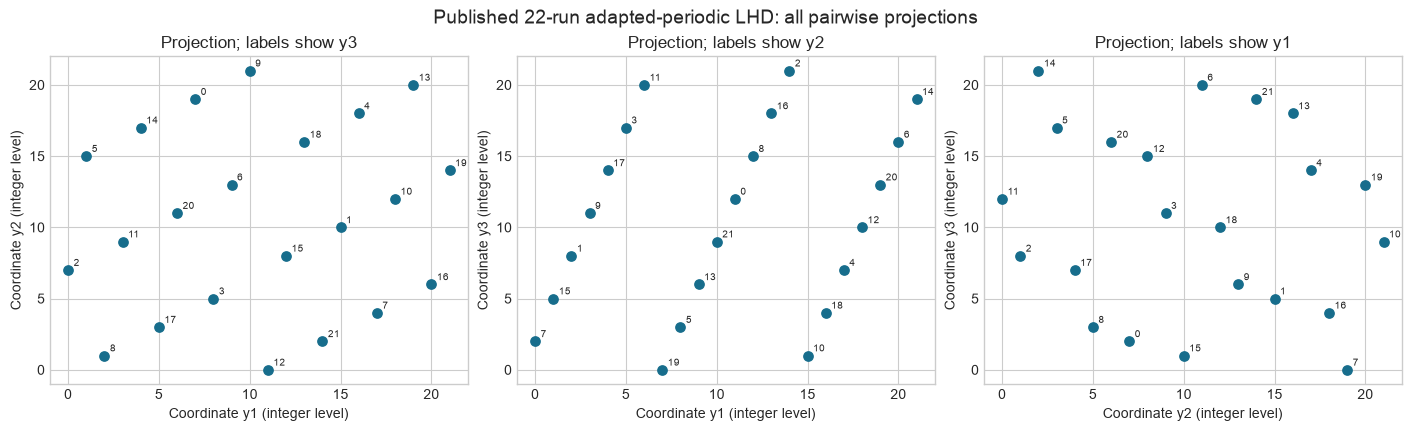

In [4]:
X_periodic_unit = (X_periodic + 0.5) / N

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)
for ax, (a, b, label) in zip(
    axes,
    [(0, 1, "y3"), (0, 2, "y2"), (1, 2, "y1")],
):
    omitted = ({0, 1, 2} - {a, b}).pop()
    ax.scatter(X_periodic[:, a], X_periodic[:, b], s=45, color="#176d8c")
    for row in X_periodic:
        ax.annotate(str(row[omitted]), (row[a], row[b]), xytext=(4, 3),
                    textcoords="offset points", fontsize=7)
    ax.set(xlabel=f"Coordinate y{a+1} (integer level)",
           ylabel=f"Coordinate y{b+1} (integer level)",
           title=f"Projection; labels show {label}")
    ax.set_xlim(-1, N); ax.set_ylim(-1, N)
fig.suptitle("Published 22-run adapted-periodic LHD: all pairwise projections", fontsize=14)
plt.show()

## 4. Understand the design

`d_min²` protects against near-duplicate multivariate runs (larger is better). `AE` penalizes all close pairs (smaller is better). Centered discrepancy compares the empirical point cloud with a uniform cube (smaller is better). Maximum absolute column correlation reveals linear alignment (smaller is better), while the minimum two-dimensional projected separation checks the weakest pairwise projection. Convex-hull volume is the fraction of the unit cube enclosed by the sampled points; it is not the same as interpolation validity, but it warns that even a Latin design leaves boundary regions geometrically unsupported.

In [5]:
def is_latin(ranks):
    ranks = np.asarray(ranks)
    n, k = ranks.shape
    return all(np.array_equal(np.sort(ranks[:, j]), np.arange(n)) for j in range(k))


def design_metrics(ranks):
    ranks = np.asarray(ranks, dtype=float)
    n, k = ranks.shape
    d2 = distance.pdist(ranks, metric="sqeuclidean")
    unit = (ranks + 0.5) / n
    corr = np.corrcoef(ranks, rowvar=False)
    upper = np.abs(corr[np.triu_indices(k, 1)])
    projected = [
        distance.pdist(ranks[:, [a, b]], metric="sqeuclidean").min()
        for a in range(k) for b in range(a + 1, k)
    ]
    hull_volume = ConvexHull(unit).volume if k <= 4 else np.nan
    return {
        "Latin": is_latin(ranks.astype(int)),
        "d_min²": d2.min(),
        "nearest-pair count": int(np.sum(np.isclose(d2, d2.min()))),
        "AE": np.sum(1.0 / d2),
        "centered discrepancy": qmc.discrepancy(unit, method="CD"),
        "max |correlation|": upper.max(),
        "weakest 2D d_min²": min(projected),
        "convex-hull volume": hull_volume,
    }


periodic_metrics = design_metrics(X_periodic)
display(pd.Series(periodic_metrics, name="published periodic design").to_frame())

d2_periodic = distance.squareform(distance.pdist(X_periodic, metric="sqeuclidean"))
np.fill_diagonal(d2_periodic, np.inf)
closest = np.argwhere(np.isclose(d2_periodic, np.min(d2_periodic)))
closest = closest[closest[:, 0] < closest[:, 1]] + 1
print(f"d_min = sqrt(69) = {np.sqrt(periodic_metrics['d_min²']):.6f}")
print("Closest run pairs (1-based):", closest.tolist())
print("Rank of [intercept, y1, y2, y3]:",
      np.linalg.matrix_rank(np.column_stack([np.ones(N), X_periodic])))

,published periodic design
Latin,True
d_min²,69.0
nearest-pair count,4
AE,1.4112
centered discrepancy,0.0031
max |correlation|,0.2727
weakest 2D d_min²,5.0
convex-hull volume,0.3838


d_min = sqrt(69) = 8.306624
Closest run pairs (1-based): [[1, 9], [2, 10], [13, 21], [14, 22]]
Rank of [intercept, y1, y2, y3]: 4


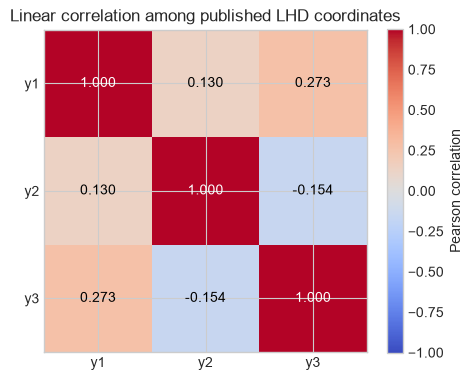

In [6]:
corr = pd.DataFrame(
    np.corrcoef(X_periodic, rowvar=False),
    index=["y1", "y2", "y3"], columns=["y1", "y2", "y3"],
)
fig, ax = plt.subplots(figsize=(5.2, 4.2))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
for i in range(K):
    for j in range(K):
        ax.text(j, i, f"{corr.iloc[i, j]:.3f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i, j]) > 0.55 else "black")
ax.set_xticks(range(K), corr.columns)
ax.set_yticks(range(K), corr.index)
ax.set_title("Linear correlation among published LHD coordinates")
fig.colorbar(im, ax=ax, label="Pearson correlation")
plt.show()

The intercept-plus-main-effects matrix has full rank, but that fact alone does not license a rich response model. With no responses, the design supports statements about geometry—not estimates of scientific factor effects. The Latin property guarantees perfect one-dimensional stratification; it does **not** guarantee orthogonal columns or uniformly filled two-dimensional projections.

## 5. Reproduce the article analysis

### 5.1 Exact worked example

The exact reconstruction above is one of the paper's two proposed routes: exploit periodic structure to search a much smaller family of LHDs. The other route is the enhanced stochastic evolutionary (ESE) algorithm. ESE repeatedly proposes swaps within columns, considers several candidates per iteration, and uses a changing acceptance threshold to escape local optima. The paper ran many starts and stopped only after no improvement in 1,000 outer loops. Its complete random streams and individual ESE matrices are unavailable, so we do not pretend a short modern heuristic is an exact rerun.

### 5.2 Published comparison tables

These compact slices are manually transcribed from Tables 3, 5, and 6 and used as article-level evidence. Boldface in the original identifies the better/equal design; here differences make the comparison explicit.

In [7]:
table3_k3 = pd.DataFrame({
    "n": np.arange(3, 13),
    "Morris–Mitchell d_min²": [6, 6, 11, 14, 17, 21, 22, 27, 29, 36],
    "ESE d_min²":            [6, 6, 11, 14, 17, 21, 22, 27, 30, 36],
})
table3_k3["ESE minus M&M"] = (
    table3_k3["ESE d_min²"] - table3_k3["Morris–Mitchell d_min²"]
)
display(table3_k3.set_index("n"))
print("Only n=11 improves in this three-dimensional slice; the paper states that 30 is optimal.")

,Morris–Mitchell d_min²,ESE d_min²,ESE minus M&M
n,,,
3,6,6,0
4,6,6,0
5,11,11,0
6,14,14,0
7,17,17,0
8,21,21,0
9,22,22,0
10,27,27,0
11,29,30,1


Only n=11 improves in this three-dimensional slice; the paper states that 30 is optimal.


In [8]:
table5_n22 = pd.DataFrame({
    "dimensions": [2, 3, 4, 5, 6, 7],
    "ESE d_min²": [18, 72, 150, 235, 325, 418],
    "periodic d_min²": [25, 69, 117, 174, 223, 270],
})
table5_n22["periodic minus ESE"] = (
    table5_n22["periodic d_min²"] - table5_n22["ESE d_min²"]
)

table6_n22 = pd.DataFrame({
    "dimensions": [2, 3, 4, 5],
    "ESE AE": [3.070, 1.357, 0.856, 0.632],
    "periodic AE": [3.070, 1.426, 0.922, 0.687],
})
table6_n22["periodic minus ESE"] = table6_n22["periodic AE"] - table6_n22["ESE AE"]

print("Table 5 slice (larger is better):")
display(table5_n22.set_index("dimensions"))
print("Table 6 slice (smaller is better; these are criterion-specific designs):")
display(table6_n22.set_index("dimensions"))

Table 5 slice (larger is better):


,ESE d_min²,periodic d_min²,periodic minus ESE
dimensions,,,
2,18,25,7
3,72,69,-3
4,150,117,-33
5,235,174,-61
6,325,223,-102
7,418,270,-148


Table 6 slice (smaller is better; these are criterion-specific designs):


,ESE AE,periodic AE,periodic minus ESE
dimensions,,,
2,3.070,3.070,0.000
3,1.357,1.426,0.069
4,0.856,0.922,0.066
5,0.632,0.687,0.055


At $n=22,k=3$, the periodic example's 69 is close to the ESE result 72, but not equal. The AE value computed for the **maximin** example should not be compared as if it were Table 6's 1.426: Table 6 reports a separately selected periodic design optimized for AE. This distinction prevents a common error—mixing optima from different objectives.

The paper's broader conclusion is nuanced: ESE generally finds the best maximin and AE designs, while periodic designs can be especially competitive when the run count is large relative to dimension. Special foldover structures also explain some cases where earlier Morris–Mitchell designs outperform ESE.

## 6. Validate against the paper

Every exactly reproducible target is checked below. A sequence match is encoded as 1/0 so that the same absolute-difference contract can be used. The ESE value 72 is deliberately listed as a contextual target rather than fabricated as a reproduction.

In [9]:
validation = pd.DataFrame([
    {"target": "Figure 1 y2 sequence match", "published": 1.0,
     "reproduced": float(np.array_equal(y2, published_y2)), "tolerance": 0.0,
     "status/explanation": "exact equation-based reconstruction"},
    {"target": "Figure 1 y3 sequence match", "published": 1.0,
     "reproduced": float(np.array_equal(y3, published_y3)), "tolerance": 0.0,
     "status/explanation": "exact equation-based reconstruction"},
    {"target": "22 unique levels in each of 3 columns", "published": 22.0,
     "reproduced": float(min(len(np.unique(X_periodic[:, j])) for j in range(K))),
     "tolerance": 0.0, "status/explanation": "Latin property"},
    {"target": "Worked example / Table 5 d_min²", "published": 69.0,
     "reproduced": periodic_metrics["d_min²"], "tolerance": 0.0,
     "status/explanation": "exact integer-grid calculation"},
    {"target": "Table 5 ESE d_min² (context only)", "published": 72.0,
     "reproduced": np.nan, "tolerance": np.nan,
     "status/explanation": "not reproduced: ESE matrix/random stream unavailable"},
])
validation["absolute difference"] = abs(validation["reproduced"] - validation["published"])
validation["relative difference"] = validation["absolute difference"] / abs(validation["published"])
display(validation.set_index("target"))

exact_rows = validation[validation["reproduced"].notna()]
assert (exact_rows["absolute difference"] <= exact_rows["tolerance"]).all()
print(f"All {len(exact_rows)} exact validation targets pass.")

,published,reproduced,tolerance,status/explanation,absolute difference,relative difference
target,,,,,,
Figure 1 y2 sequence match,1.0,1.0,0.0,exact equation-based reconstruction,0.0,0.0
Figure 1 y3 sequence match,1.0,1.0,0.0,exact equation-based reconstruction,0.0,0.0
22 unique levels in each of 3 columns,22.0,22.0,0.0,Latin property,0.0,0.0
Worked example / Table 5 d_min²,69.0,69.0,0.0,exact integer-grid calculation,0.0,0.0
Table 5 ESE d_min² (context only),72.0,NaN,NaN,not reproduced: ESE matrix/random stream unava...,NaN,NaN


All 4 exact validation targets pass.


## 7. Go beyond the paper

Everything from here onward is new notebook analysis, not a claim about the article.

### 7.1 `pydoe` and 2,000 random Latin hypercubes

All candidates have the same budget ($n=22$), dimension ($k=3$), and one point per stratum. `pydoe.lhs(..., criterion="centermaximin")` samples many random Latin hypercubes and returns the best separation it sees; this is useful and reproducible, but it is not ESE. We also apply a small greedy swap search as a transparent teaching analogue. It accepts only lexicographic improvements in minimum distance, number of closest pairs, and AE potential, so it can become trapped in a local optimum.

In [10]:
def ranks_from_centered_lhs(x):
    ranks = np.rint(np.asarray(x) * len(x) - 0.5).astype(int)
    assert is_latin(ranks)
    return ranks


X_py_random = ranks_from_centered_lhs(lhs(K, samples=N, criterion="center", seed=SEED))
X_py_maximin = ranks_from_centered_lhs(
    lhs(K, samples=N, criterion="centermaximin", iterations=2000, seed=SEED)
)


def exchange_score(ranks):
    d2 = distance.pdist(ranks, metric="sqeuclidean")
    minimum = d2.min()
    return (minimum, -int(np.sum(np.isclose(d2, minimum))), -float(np.sum(1 / d2)))


def greedy_swap_search(start, seed, proposals=30000):
    # Teaching heuristic, deliberately simpler than the article's ESE.
    rng = np.random.default_rng(seed)
    current = np.array(start, copy=True)
    score = exchange_score(current)
    accepted = 0
    for _ in range(proposals):
        rows = rng.choice(len(current), size=2, replace=False)
        col = rng.integers(current.shape[1])
        trial = current.copy()
        trial[rows, col] = trial[rows[::-1], col]
        trial_score = exchange_score(trial)
        if trial_score > score:
            current, score = trial, trial_score
            accepted += 1
    assert is_latin(current)
    return current, accepted


X_greedy, greedy_accepted = greedy_swap_search(X_py_maximin, SEED + 1)
print(f"Greedy teaching search accepted {greedy_accepted} of 30,000 proposed swaps.")

rng = np.random.default_rng(SEED)
B = 2000
random_designs = np.empty((B, N, K), dtype=int)
for b in range(B):
    random_designs[b] = np.column_stack([rng.permutation(N) for _ in range(K)])

random_metrics = pd.DataFrame([design_metrics(x) for x in random_designs])

named_designs = {
    "published periodic": X_periodic,
    "pydoe random": X_py_random,
    "pydoe centermaximin (2,000 candidates)": X_py_maximin,
    "greedy swap teaching heuristic": X_greedy,
}
comparison = pd.DataFrame({name: design_metrics(x) for name, x in named_designs.items()}).T
display(comparison)

Greedy teaching search accepted 103 of 30,000 proposed swaps.


,Latin,d_min²,nearest-pair count,AE,centered discrepancy,max |correlation|,weakest 2D d_min²,convex-hull volume
published periodic,True,69.0,4,1.4112,0.0031,0.2727,5.0,0.3838
pydoe random,True,14.0,2,1.75,0.0047,0.2885,2.0,0.3966
"pydoe centermaximin (2,000 candidates)",True,24.0,1,1.5939,0.0041,0.2705,2.0,0.4022
greedy swap teaching heuristic,True,62.0,3,1.3992,0.0025,0.0728,2.0,0.4421


In [11]:
def percentile_against_random(value, sample, higher_is_better):
    sample = np.asarray(sample)
    return 100 * np.mean(sample <= value) if higher_is_better else 100 * np.mean(sample >= value)


quality_percentiles = pd.DataFrame({
    name: {
        "d_min² percentile": percentile_against_random(
            design_metrics(x)["d_min²"], random_metrics["d_min²"], True),
        "AE percentile": percentile_against_random(
            design_metrics(x)["AE"], random_metrics["AE"], False),
        "discrepancy percentile": percentile_against_random(
            design_metrics(x)["centered discrepancy"], random_metrics["centered discrepancy"], False),
        "low-correlation percentile": percentile_against_random(
            design_metrics(x)["max |correlation|"], random_metrics["max |correlation|"], False),
    }
    for name, x in named_designs.items()
}).T
display(quality_percentiles)
print("Percentiles are empirical among 2,000 random LHDs; 100 is favorable.")

,d_min² percentile,AE percentile,discrepancy percentile,low-correlation percentile
published periodic,100.00,100.00,99.6,52.90
pydoe random,94.45,85.40,55.7,47.90
"pydoe centermaximin (2,000 candidates)",99.90,99.75,79.3,53.45
greedy swap teaching heuristic,100.00,100.00,100.0,98.15


Percentiles are empirical among 2,000 random LHDs; 100 is favorable.


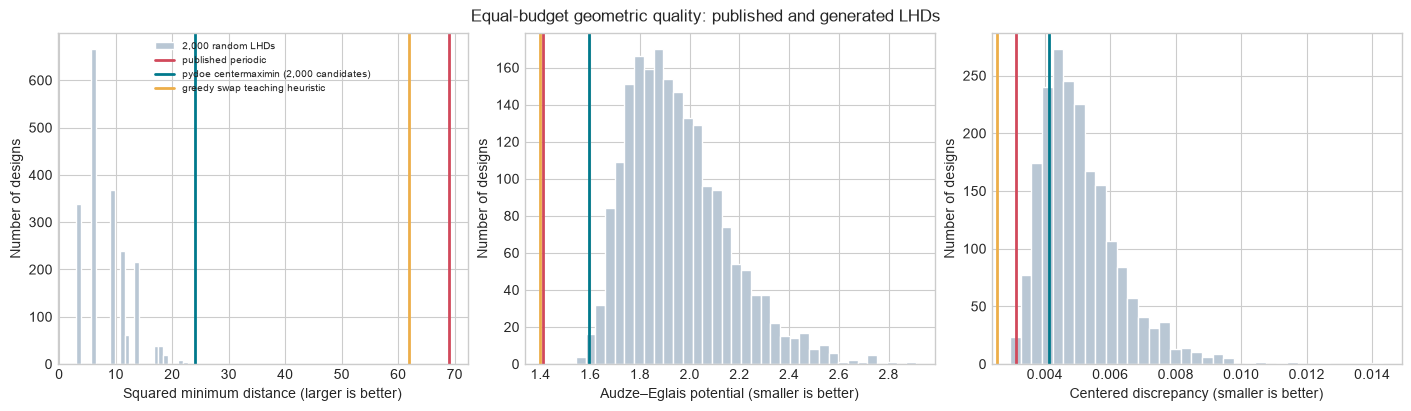

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
specs = [
    ("d_min²", "Squared minimum distance (larger is better)"),
    ("AE", "Audze–Eglais potential (smaller is better)"),
    ("centered discrepancy", "Centered discrepancy (smaller is better)"),
]
colors = {"published periodic": "#d1495b", "pydoe centermaximin (2,000 candidates)": "#00798c",
          "greedy swap teaching heuristic": "#edae49"}
for ax, (metric, xlabel) in zip(axes, specs):
    ax.hist(random_metrics[metric], bins=35, color="#b9c7d4", edgecolor="white",
            label="2,000 random LHDs")
    for name, color in colors.items():
        ax.axvline(comparison.loc[name, metric], color=color, linewidth=2, label=name)
    ax.set(xlabel=xlabel, ylabel="Number of designs")
axes[0].legend(fontsize=7)
fig.suptitle("Equal-budget geometric quality: published and generated LHDs")
plt.show()

The periodic construction is exceptional for minimum distance compared with ordinary random LHDs. Yet the metric table also demonstrates why “space filling” is plural: selecting on $d_{\min}$ need not simultaneously minimize discrepancy or correlation. The short greedy search's result is an algorithmic diagnostic, not an attempted replacement for the paper's ESE computation.

### 7.2 Approximate covering radius

Using the same fixed Sobol probe points for every design, we estimate the largest distance from anywhere in the cube to its nearest run. Smaller values mean fewer large holes. This is an approximation, not a published statistic.

In [13]:
probe = qmc.Sobol(d=K, scramble=True, seed=SEED).random_base2(15)
covering = {}
for name, ranks in named_designs.items():
    unit = (ranks + 0.5) / N
    nearest, _ = cKDTree(unit).query(probe, k=1)
    covering[name] = {
        "approx max nearest distance": nearest.max(),
        "95th percentile nearest distance": np.quantile(nearest, 0.95),
        "mean nearest distance": nearest.mean(),
    }
display(pd.DataFrame(covering).T)

,approx max nearest distance,95th percentile nearest distance,mean nearest distance
published periodic,0.4293,0.2813,0.1864
pydoe random,0.5257,0.3462,0.2077
"pydoe centermaximin (2,000 candidates)",0.4950,0.3183,0.1983
greedy swap teaching heuristic,0.4414,0.2837,0.1877


### 7.3 Response-based synthetic benchmark

Geometry should ultimately be judged against a use. We define, before looking at results, a smooth deterministic three-input simulator with periodic main effects, curvature, and an $x_1x_2$ interaction:

$$f(x)=\sin(2\pi x_1)+0.7\cos(2\pi x_2)+0.5(x_3-0.5)^2+0.8\sin(\pi x_1x_2).$$

Each design receives exactly 22 evaluations. A Gaussian process with the same fixed isotropic RBF kernel is fitted without hyperparameter optimization, and RMSE is measured on the same 4,096-point Sobol test set. One hundred newly randomized LHDs provide a distribution—not a cherry-picked seed. There is no observation noise. This benchmark illustrates interpolation only; it does not reconstruct a response from the paper.

In [14]:
def synthetic_simulator(x):
    x = np.asarray(x)
    return (
        np.sin(2 * np.pi * x[:, 0])
        + 0.7 * np.cos(2 * np.pi * x[:, 1])
        + 0.5 * (x[:, 2] - 0.5) ** 2
        + 0.8 * np.sin(np.pi * x[:, 0] * x[:, 1])
    )


kernel = ConstantKernel(1.0, constant_value_bounds="fixed") * RBF(
    length_scale=0.22, length_scale_bounds="fixed"
)
test_x = qmc.Sobol(d=K, scramble=True, seed=SEED + 10).random_base2(12)
test_y = synthetic_simulator(test_x)


def fixed_gp_rmse(ranks):
    x = (np.asarray(ranks) + 0.5) / N
    gp = GaussianProcessRegressor(
        kernel=kernel, alpha=1e-10, optimizer=None, normalize_y=True
    )
    gp.fit(x, synthetic_simulator(x))
    prediction = gp.predict(test_x)
    return float(np.sqrt(np.mean((test_y - prediction) ** 2)))


named_rmse = pd.Series(
    {name: fixed_gp_rmse(ranks) for name, ranks in named_designs.items()},
    name="fixed-kernel GP RMSE",
)

rng_response = np.random.default_rng(SEED + 20)
response_random = [
    np.column_stack([rng_response.permutation(N) for _ in range(K)])
    for _ in range(100)
]
random_rmse = np.array([fixed_gp_rmse(x) for x in response_random])

display(named_rmse.to_frame())
print(pd.Series(random_rmse).describe(percentiles=[0.05, 0.5, 0.95]).rename("100 random-LHD RMSEs"))

,fixed-kernel GP RMSE
published periodic,0.3422
pydoe random,0.4343
"pydoe centermaximin (2,000 candidates)",0.3830
greedy swap teaching heuristic,0.3755


count    100.0000
mean       0.3959
std        0.0485
min        0.2764
5%         0.3154
50%        0.3972
95%        0.4735
max        0.5005
Name: 100 random-LHD RMSEs, dtype: float64


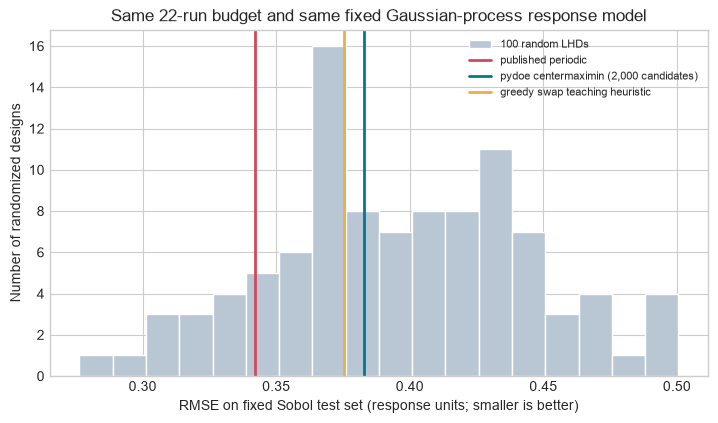

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.hist(random_rmse, bins=18, color="#b9c7d4", edgecolor="white", label="100 random LHDs")
for name, color in colors.items():
    ax.axvline(named_rmse[name], color=color, linewidth=2, label=name)
ax.set(
    xlabel="RMSE on fixed Sobol test set (response units; smaller is better)",
    ylabel="Number of randomized designs",
    title="Same 22-run budget and same fixed Gaussian-process response model",
)
ax.legend(fontsize=8)
plt.show()

The response benchmark can rank designs differently from a single geometric criterion because surrogate error depends on the unknown function and model assumptions. A good maximin LHD is prudent generic protection, not a theorem that it will be best for every simulator. The test points are inside the stated cube, but many lie outside the finite design's convex hull; predictions there are geometrical extrapolations despite remaining within factor bounds.

## 8. Practitioner conclusions

* **What DoE made possible.** Twenty-two runs cover every one-dimensional stratum for each of three inputs and deliberately separate multivariate points. Ad hoc random sampling can cluster; the benchmark quantifies how unusual the published separation is.
* **What one-factor-at-a-time would miss.** OFAT traces coordinate axes around a baseline. It does not cover joint projections well and cannot reveal a general interaction surface such as the synthetic $x_1x_2$ term without bespoke paths.
* **What is supported.** The design itself supports claims about Latin stratification, distances, projections, correlation, and geometric coverage. It supports no scientific factor effect because the article supplies no response observations. Main effects would be algebraically estimable, but richer response terms require a separately justified model.
* **Where prediction is trustworthy.** Most credible prediction is interpolation near runs. “Inside the rectangular factor bounds” is not sufficient: sparse corners and points outside the design's convex hull depend more strongly on kernel/model assumptions.
* **Design versus response-model limitations.** Holes, correlation, and weak projections are design limitations; kernel smoothness, stationarity, and length scale are surrogate limitations. Improving one does not automatically repair the other.
* **Assumptions that matter.** Inputs are quantitative and scalable; the simulator is sufficiently smooth for distance-based filling to help; repeated deterministic runs add little; all inputs share an appropriate metric after scaling.
* **Mistakes to avoid.** Do not confuse LHD with an arbitrary random sample, compare squared distances with ordinary distances, mix maximin and AE optima, optimize only one geometry metric, or report a short stochastic search as the authors' ESE result.

The paper's most transferable lesson is that design quality is multi-objective. Latin stratification prevents collapse, maximin spacing avoids near duplicates, and projection/correlation/discrepancy diagnostics reveal weaknesses that a single optimum can hide.

## 9. Reproducibility metadata

The following cell records the executed environment and the fixed experimental choices. The common environment is pinned in [`requirements.txt`](requirements.txt). The article's OA PDF was inspected locally for transcription and visual verification, then excluded from repository artifacts.

In [16]:
metadata = pd.Series({
    "execution date": "2026-08-01",
    "Python": platform.python_version(),
    "pydoe": pydoe.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": scipy.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": matplotlib.__version__,
    "global seed": SEED,
    "random geometry replications": B,
    "random response replications": len(random_rmse),
    "Sobol covering probes": len(probe),
    "Sobol response test points": len(test_x),
    "source PDF SHA-256": "d419ea58f81f5ca394ef6f99c60d48d895c8b7772c5a3d6f6a4fedd8743d2165",
})
display(metadata.to_frame("value"))

assert is_latin(X_periodic)
assert periodic_metrics["d_min²"] == 69
assert len(random_metrics) == B
assert np.isfinite(random_rmse).all()
print("Final integrity checks passed; notebook executed end to end.")

,value
execution date,2026-08-01
Python,3.13.2
pydoe,1.3.1.dev11+geca1a2598
numpy,2.3.4
pandas,3.0.0
scipy,1.16.2
scikit-learn,1.9.0
matplotlib,3.11.1
global seed,2011
random geometry replications,2000


Final integrity checks passed; notebook executed end to end.
